## TODOs: Chunking (Step 4)

- Set up imports: `HybridChunker`, `HuggingFaceTokenizer`, `AutoTokenizer`, `DoclingDocument`
- Configure `HybridChunker`: `tokenizer`, `max_tokens=512`, `merge_peers=True`
- Load the JSON saved in Step 3 back into a `DoclingDocument` object via `DoclingDocument.load_from_json(path)` (no re-parsing of the PDF)
- Run `chunker.chunk(dl_doc=doc)`, iterate over chunks, apply `chunker.contextualize()`
- Inspect chunks: count, token distribution (min/max/median), spot-check samples, check shortest/degenerate chunks
- Verify that bbox/page_no metadata is preserved per chunk (`chunk.meta.doc_items`)
- Define a Pydantic schema for a chunk in `schemas.py` (`chunk_id`, `doc_id`, `text`, `contextualized_text`, `page_no`, `bbox`, `heading_path`, `token_count`)
- Generate stable, reproducible chunk IDs
- Save chunks as JSONL (basis for caching in Step 5 and embedding in Step 6)
- Once everything works in the notebook → move the logic into `ingestion.py`

In [3]:
import os
os.environ["TORCHDYNAMO_DISABLE"] = "1"
import json
from docling.chunking import HybridChunker
from docling_core.transforms.chunker.tokenizer.huggingface import HuggingFaceTokenizer
from docling_core.types.doc import DoclingDocument
from backend.chunk_schema import Chunk
from pathlib import Path
from transformers import AutoTokenizer
from backend.config import settings
import jsonlines
import backend.doc_processing as hf
import matplotlib.pyplot as plt

In [ ]:
MAX_TOKENS = 512
CEILING = MAX_TOKENS + 128

In [2]:
tokenizer = HuggingFaceTokenizer(
    tokenizer=AutoTokenizer.from_pretrained("BAAI/bge-m3"),
    max_tokens=512,  # explizit setzen, sonst wird model_max_length verwendet
)
hyb_chunker = HybridChunker(
    tokenizer=tokenizer,
    merge_peers=True,
)

In [3]:
print(settings.DOCUMENTS_OUT_DIR)

C:\Users\admin\Programming\RAG-Systems\classic-RAG\Classic-RAG\data\output_docs


In [ ]:
def merge_chunks(a:Chunk, b:Chunk) -> Chunk:
    if a.doc_id != b.doc_id:
        raise ValueError(f"Cannot merge two chunks of different documents:\ndoc_id a:{a.doc_id}\ndoc_id b:{b.doc_id}")
    a = a.model_copy(deep=True)
    a.text = a.text +"\n" + b.text
    a.contextualized_text = a.contextualized_text +"\n"+ b.contextualized_text
    a.meta.doc_items = a.meta.doc_items + b.meta.doc_items
    a.token_count = tokenizer.count_tokens(a.contextualized_text)
    return a

In [ ]:
hashes = hf.hash_files(settings.DOCUMENTS_IN_DIR)

settings.CHUNKS_OUT_DIR.mkdir(parents=True, exist_ok=True)
with jsonlines.open(settings.CHUNKS_OUT_DIR/"chunks.jsonl", mode="w") as writer:
    chunk_no = 0
    for stem, doc_id in hashes:
        fp = list(settings.DOCUMENTS_OUT_DIR.glob(f"{stem}.json"))[0]
        doc = DoclingDocument.load_from_json(fp)
        chunk_buffer: Chunk | None = None
        
        for i,chunk in enumerate(hyb_chunker.chunk(dl_doc=doc)):
            ctx = hyb_chunker.contextualize(chunk)
            c = Chunk(
                chunk_id="",
                doc_id=doc_id,
                text=chunk.text,
                contextualized_text=ctx,
                token_count=tokenizer.count_tokens(ctx),
                meta=chunk.meta
            )
            if chunk_buffer is None:
                chunk_buffer = c
                continue
            
            is_small = chunk_buffer.token_count < 100 or c.token_count < 100
            fits = chunk_buffer.token_count + c.token_count < CEILING
            if is_small and fits:
                chunk_buffer = merge_chunks(chunk_buffer, c)
            else:
                chunk_buffer.chunk_id= str(chunk_no)
                writer.write(chunk_buffer.model_dump(mode="json"))
                chunk_no += 1
                chunk_buffer  = c
        if chunk_buffer is not None:
            chunk_buffer.chunk_id = str(chunk_no)
            writer.write(chunk_buffer.model_dump(mode="json"))
            chunk_no +=1
                
            
    

In [4]:
chunks_path = list(settings.CHUNKS_OUT_DIR.glob("*.jsonl"))[0]
with jsonlines.open(chunks_path) as reader:
    loaded_chunks = [Chunk.model_validate(row) for row in reader]

In [5]:
import pprint

pprint.pprint(loaded_chunks[0])

Chunk(chunk_id='0', doc_id='f631a60af3315700112400d55bcecbf264094863cd32660ae0a208dd7130de9c', text='zur  Festlegung  harmonisierter Vorschriften für künstliche Intelligenz und zur Änderung der Verordnungen (EG) Nr. 300/2008, (EU) Nr. 167/2013, (EU) Nr. 168/2013, (EU) 2018/858, (EU) 2018/1139 und (EU) 2019/2144 sowie der Richtlinien 2014/90/EU, (EU) 2016/797 und (EU) 2020/1828 (Verordnung über künstliche Intelligenz)\n(Text von Bedeutung für den EWR)\nDAS EUROPÄISCHE PARLAMENT UND DER RAT DER EUROPÄISCHEN UNION -\ngestützt  auf  den  Vertrag  über  die  Arbeitsweise  der  Europäischen  Union,  insbesondere  auf  die  Artikel  16  und  114,\nauf  Vorschlag  der  Europäischen  Kommission,\nnach Zuleitung  des  Entwurfs  des  Gesetzgebungsakts  an  die  nationalen  Parlamente,\nnach Stellungnahme des Europäischen Wirtschafts- und Sozialausschusses ( 1 ),\nnach Stellungnahme der Europäischen Zentralbank ( 2 ),\nnach Stellungnahme des Ausschusses der Regionen ( 3 ),\ngemäß dem ordentlichen 

In [5]:
tokens  = [chunk.token_count for chunk in loaded_chunks]

In [8]:
print("Number of chunks:", len(loaded_chunks))


Number of chunks: 406


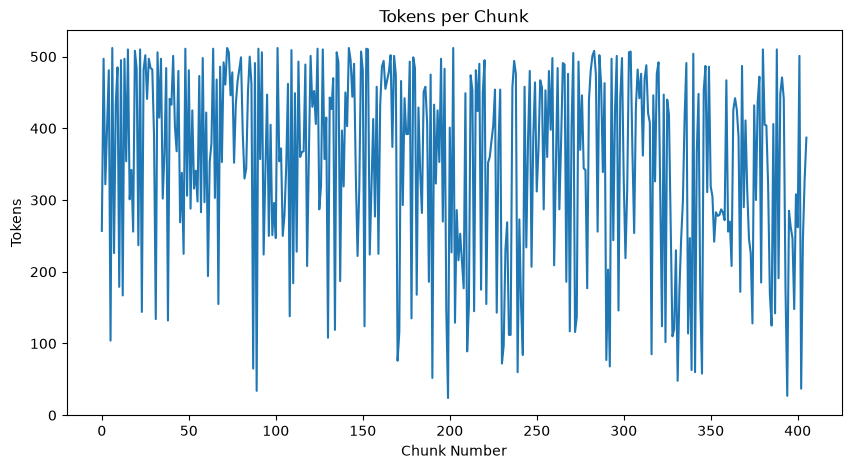

In [9]:
fig, ax = plt.subplots(figsize=(10,5))
ax.set_title(label="Tokens per Chunk")
ax.set_ylabel(ylabel="Tokens")
ax.set_xlabel(xlabel="Chunk Number")
ax.plot(range(len(loaded_chunks)), tokens )
plt.show()

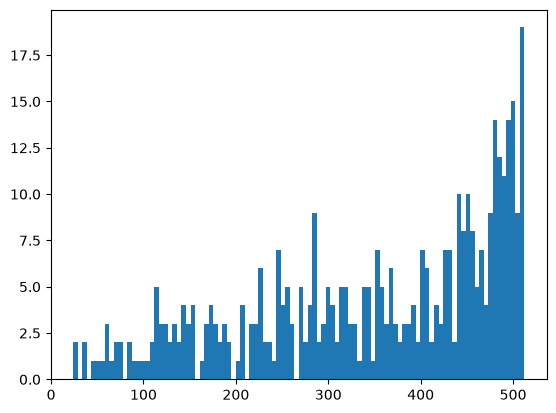

In [11]:
plt.hist(tokens, bins=100)
plt.show()

### Inspecting small Chunks

In [10]:
toks_per_chunks = zip(list(range(len(loaded_chunks))), tokens)
toks_per_chunks = sorted(toks_per_chunks, key= lambda tup: tup[1])

print(toks_per_chunks[:20])

[(199, 24), (394, 27), (89, 34), (402, 37), (331, 48), (190, 52), (345, 58), (239, 60), (341, 60), (339, 63), (87, 65), (292, 68), (230, 72), (170, 76), (290, 77), (242, 84), (316, 85), (210, 89), (231, 97), (324, 102)]


In [12]:
for chunk_idx, _ in toks_per_chunks[:4]:
    print(loaded_chunks[chunk_idx].contextualized_text)
    print("----------------------------------------------")

ABSCHNITT 3
Pflichten der Anbieter  und  Betreiber  von Hochrisiko-KI-Systemen und anderer Beteiligter
----------------------------------------------
ANHANG X
Rechtsvorschriften  der  Union  über  IT-Großsysteme  im  Raum  der  Freiheit,  der  Sicherheit  und  des  Rechts
----------------------------------------------
vom 13. Juni 2024
Fragebogen ausarbeiten, um den Betreibern die Einhaltung der Vorschriften zu erleichtern und den Verwaltungsaufwand für sie zu  verringern.
----------------------------------------------
Abschnitt 1
Wenn  der  Energieverbrauch  des  Modells  nicht  bekannt  ist,  kann  für  Buchstabe  e  der  Energieverbrauch  auf Informationen  über  die  eingesetzten  Rechenressourcen gestützt  werden.
----------------------------------------------


In [15]:
for chunk_idx, _ in toks_per_chunks[:4]:
    print(loaded_chunks[chunk_idx].meta.doc_items)
    print("----------------------------------------------")

[DocItem(self_ref='#/texts/842', parent=RefItem(cref='#/body'), children=[], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.TEXT: 'text'>, prov=[ProvenanceItem(page_no=62, bbox=BoundingBox(l=121.889999389, t=748.6730311714375, r=473.3690964189999, b=740.0743411714376, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 90))], source=[], comments=[])]
----------------------------------------------
[DocItem(self_ref='#/texts/2402', parent=RefItem(cref='#/body'), children=[], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.TEXT: 'text'>, prov=[ProvenanceItem(page_no=139, bbox=BoundingBox(l=138.44538725200002, t=746.543241007254, r=456.8695391251031, b=739.1214796739206, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 113))], source=[], comments=[])]
----------------------------------------------
[DocItem(self_ref='#/texts/275', parent=RefItem(cref='#/body'), children=[], content_layer=<ContentLayer.BODY